In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
import pandas as pd

In [2]:
ds = xr.open_dataset("xboutput.nc")

y_profile = ds.globaly.mean(dim="nx").values

width = 2000
middle = np.max(y_profile) // 2
bottom = int(middle - (width / 2))
top = int(middle + (width / 2))

matching_indices = np.where((y_profile >= bottom) & (y_profile <= top))[0]

if len(matching_indices) == 0:
    raise ValueError("No grid points found within the specified y-coordinate range.")

bottom_idx = matching_indices[0]
top_idx = matching_indices[-1] + 1

ds = ds.isel(ny=slice(bottom_idx, top_idx))

wave_params = {}
with open("jonswap.txt", "r") as f:
    for line in f:
        if "=" in line:
            key, value = line.split("=")
            wave_params[key.strip()] = float(value.strip())

Animation saved as wave_animation.gif


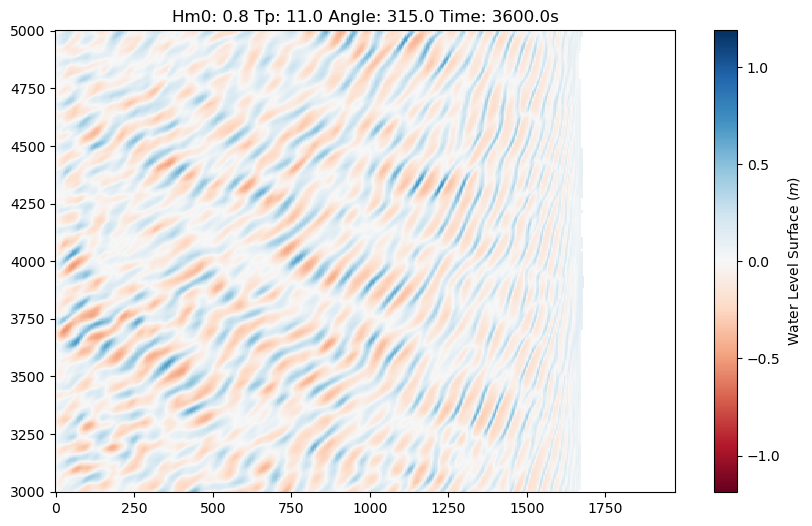

In [3]:
# 2d animation
x = ds['globalx']
y = ds['globaly']
time = ds['globaltime']

fig, ax = plt.subplots(figsize=(10, 8))

vmin = -float(ds['zs'].max())
vmax = float(ds['zs'].max())
norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

quad = ax.pcolormesh(ds.globalx, ds.globaly, ds['zs'].isel(globaltime=0), norm=norm, cmap='RdBu', shading='auto')

fig.colorbar(quad, label='Water Level Surface ($m$)')

ax.set_aspect('equal')

def update(frame):
    quad.set_array(ds['zs'].isel(globaltime=frame).values.ravel())
    ax.set_title(f"Hm0: {wave_params['Hm0']} Tp: {wave_params['Tp']} Angle: {wave_params['mainang']} Time: {ds.globaltime[frame].values:.1f}s")
    return quad,

ani = animation.FuncAnimation(fig, update, frames=len(ds.globaltime), blit=True)
ani.save('wave_animation.gif', writer='pillow', fps=10)
print("Animation saved as wave_animation.gif")

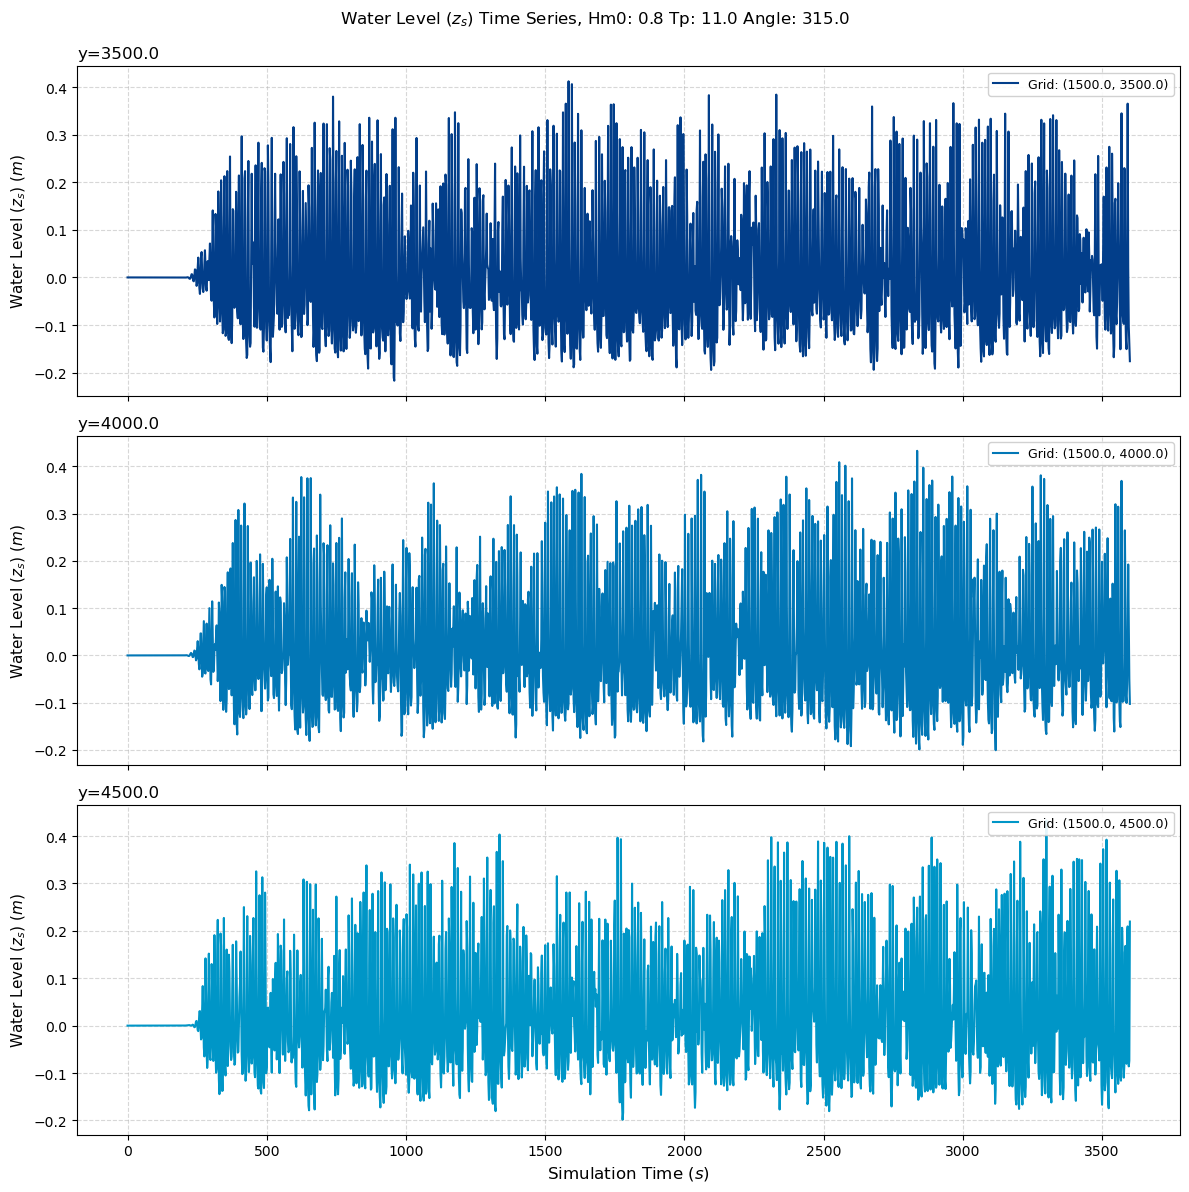

In [3]:
target_points = [
    (1500.0, 3500.0),   
    (1500.0, 4000.0),   
    (1500.0, 4500.0)   
]

X_grid = ds['globalx'].values
Y_grid = ds['globaly'].values
time = ds['globaltime'].values

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

colors = ['#023e8a', '#0277b6', '#0096c7']

for idx, (target_x, target_y) in enumerate(target_points):
    
    distance = (X_grid - target_x)**2 + (Y_grid - target_y)**2
    
    ny_idx, nx_idx = np.unravel_index(np.argmin(distance), distance.shape)
    
    actual_x = X_grid[ny_idx, nx_idx]
    actual_y = Y_grid[ny_idx, nx_idx]
    
    zs_series = ds['zs'].isel(ny=ny_idx, nx=nx_idx).values
    
    ax = axes[idx]

    ax.plot(time, zs_series, color=colors[idx], linewidth=1.5,
            label=f"Grid: ({actual_x:.1f}, {actual_y:.1f})")

    ax.set_title(f"y={actual_y:.1f}", loc='left')
    ax.set_ylabel('Water Level ($z_s$) ($m$)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

axes[-1].set_xlabel('Simulation Time ($s$)', fontsize=12)
fig.suptitle(f"Water Level ($z_s$) Time Series, Hm0: {wave_params['Hm0']} Tp: {wave_params['Tp']} Angle: {wave_params['mainang']}", y=0.99)

plt.tight_layout()
plt.show()

3D Animation saved as wave_3d_final.gif


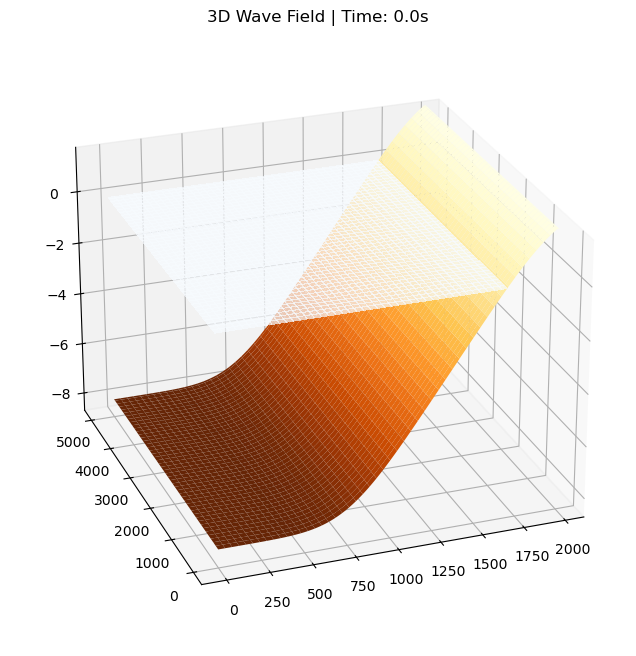

In [5]:
# 3d animation
X = ds['globalx'].isel(ny=0).values  # slice along the ny dimension
Y = ds['globaly'].isel(nx=0).values  # slice along the nx dimension
X_mesh, Y_mesh = np.meshgrid(X, Y)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

bed = ds['zb'].isel(globaltime=0).values

def update(frame):
    ax.clear()
    surface_deviation = ds['zs'].isel(globaltime=frame).values
    ax.plot_surface(X_mesh, Y_mesh, bed, cmap='YlOrBr_r', linewidth=0, antialiased=True)
    surf = ax.plot_surface(X_mesh, Y_mesh, surface_deviation, cmap='Blues', linewidth=0, antialiased=False, alpha=0.7)
    ax.set_zlim(np.min(bed)-0.5, 1.5)
    ax.set_title(f"3D Wave Field | Time: {ds.globaltime[frame].values:.1f}s")
    ax.view_init(elev=25, azim=-110)
    return surf,

ani = animation.FuncAnimation(fig, update, frames=len(ds.globaltime), blit=False)
ani.save('wave_3d_final.gif', writer='pillow', fps=6)
print("3D Animation saved as wave_3d_final.gif")

In [4]:
# crop time after looking at wave outputs
ds = ds.sel(globaltime=slice(400, None))

Sediment vector animation saved as sediment_vectors.gif


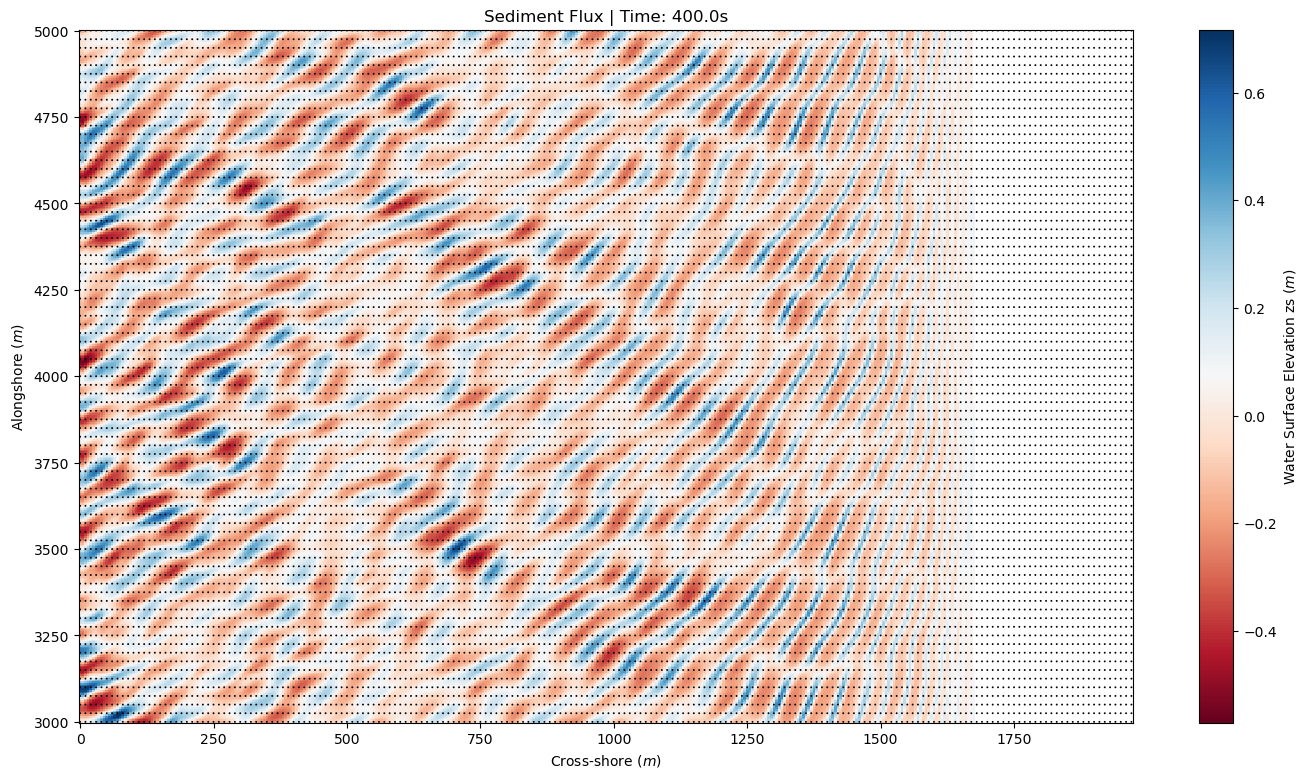

In [41]:
# animate sediment flux vector field
fig, ax = plt.subplots(figsize=(17, 9))

# using zs (Water Surface Elevation) for the background
background = ds['zs'].isel(globaltime=0)
im = ax.pcolormesh(X_mesh, Y_mesh, background, cmap='RdBu', shading='auto')
fig.colorbar(im, label='Water Surface Elevation zs ($m$)')

skip = (slice(None, None, 8), slice(None, None, 8)) 

u_full = ds['Susg'].isel(globaltime=-1).sum(dim='sediment_classes').values
v_full = ds['Svsg'].isel(globaltime=-1).sum(dim='sediment_classes').values

X_plot = X_mesh[skip]
Y_plot = Y_mesh[skip]
u_plot = u_full[skip]
v_plot = v_full[skip]

Q = ax.quiver(X_plot, Y_plot, u_plot, v_plot, color='k', scale=.05, width=0.002)

ax.set_title('Sediment Flux')
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')

def update(frame):
    im.set_array(ds['zs'].isel(globaltime=frame).values.ravel())
    
    u = ds['Susg'].isel(globaltime=frame).sum(dim='sediment_classes').values[skip]
    v = ds['Svsg'].isel(globaltime=frame).sum(dim='sediment_classes').values[skip]
    
    Q.set_UVC(u, v)
    
    ax.set_title(f"Sediment Flux | Time: {ds.globaltime[frame].values:.1f}s")
    return im, Q

ani = animation.FuncAnimation(fig, update, frames=len(ds.globaltime), blit=False)
ani.save('sediment_vectors.gif', writer='pillow', fps=8)
print("Sediment vector animation saved as sediment_vectors.gif")

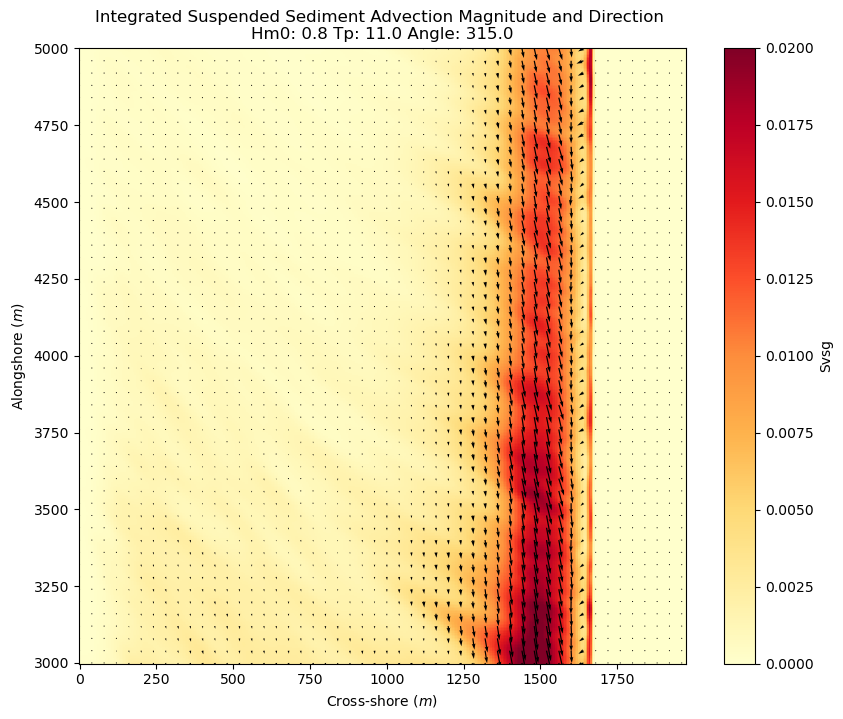

In [35]:
X = ds['globalx'].isel(ny=0).values  
Y = ds['globaly'].isel(nx=0).values  
X_mesh, Y_mesh = np.meshgrid(X, Y)

time = ds['globaltime'].values
dt = np.diff(time) 
dt = np.append(dt, dt[-1]) 

ny, nx = len(Y), len(X)
u_sum = np.zeros((ny, nx))
v_sum = np.zeros((ny, nx))

for i in range(len(time)):
    u_step = ds['Susg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    v_step = ds['Svsg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    
    u_sum += u_step
    v_sum += v_step

mag_sum = np.sqrt(u_sum**2 + v_sum**2)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(X_mesh, Y_mesh, mag_sum, cmap='YlOrRd', vmin=0, vmax=.02, shading='auto')
cbar = fig.colorbar(im, label='Svsg')

skip = (slice(None, None, 8), slice(None, None, 8))
Q = ax.quiver(X_mesh[skip], Y_mesh[skip], u_sum[skip], v_sum[skip], color='black', scale=.5, width=0.002)

ax.set_title(f"Integrated Suspended Sediment Advection Magnitude and Direction \nHm0: {wave_params['Hm0']} Tp: {wave_params['Tp']} Angle: {wave_params['mainang']}")
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')
ax.set_aspect('equal')
plt.show()

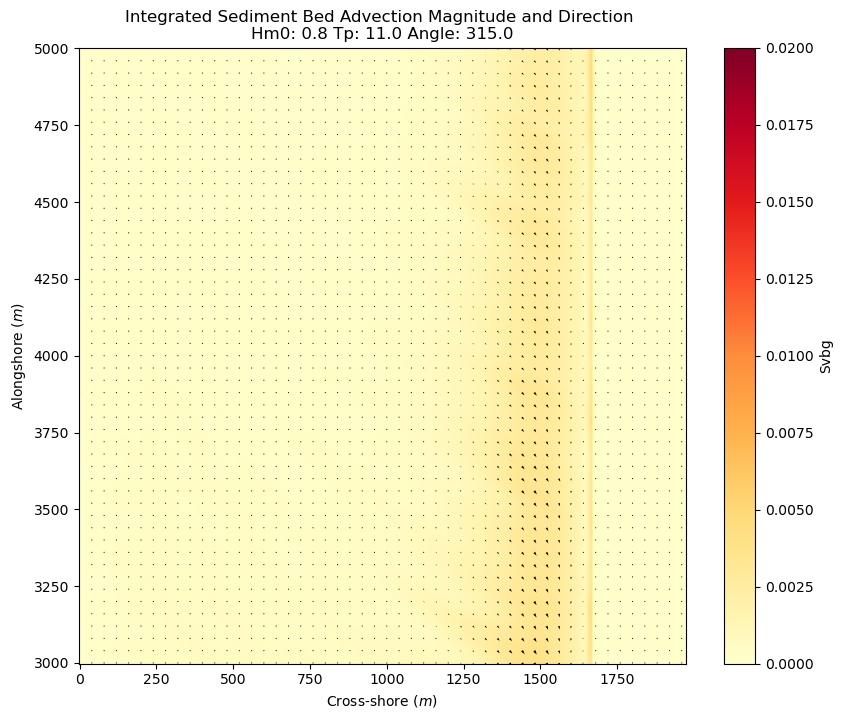

In [34]:
X = ds['globalx'].isel(ny=0).values  
Y = ds['globaly'].isel(nx=0).values  
X_mesh, Y_mesh = np.meshgrid(X, Y)

time = ds['globaltime'].values
dt = np.diff(time) 
dt = np.append(dt, dt[-1]) 

ny, nx = len(Y), len(X)
u_sum = np.zeros((ny, nx))
v_sum = np.zeros((ny, nx))

for i in range(len(time)):
    u_step = ds['Subg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    v_step = ds['Svbg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    
    u_sum += u_step
    v_sum += v_step

mag_sum = np.sqrt(u_sum**2 + v_sum**2)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(X_mesh, Y_mesh, mag_sum, cmap='YlOrRd', vmin=0, vmax=.02, shading='auto')
cbar = fig.colorbar(im, label='Svbg')

skip = (slice(None, None, 8), slice(None, None, 8))
Q = ax.quiver(X_mesh[skip], Y_mesh[skip], u_sum[skip], v_sum[skip], color='black', scale=.5, width=0.002)

ax.set_title(f"Integrated Sediment Bed Advection Magnitude and Direction \nHm0: {wave_params['Hm0']} Tp: {wave_params['Tp']} Angle: {wave_params['mainang']}")
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')
ax.set_aspect('equal')
plt.show()

In [ ]:
# plot sedimentation/erosion 3d
sedero = ds['sedero'].isel(globaltime=-1).values

limit = .5*max(abs(sedero.min()), abs(sedero.max()))
norm = Normalize(vmin=-limit, vmax=limit)

colors = cm.RdBu(norm(sedero))

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X_mesh, Y_mesh, bed, facecolors=colors, linewidth=0, antialiased=True, shade=False)

m = cm.ScalarMappable(cmap=cm.RdBu, norm=norm)
m.set_array(sedero)
fig.colorbar(m, ax=ax, label='Cumulative Sedimentation/Erosion (m)')

ax.set_title('Cumulative Sedimentation/Erosion')
ax.view_init(elev=25, azim=-110)
plt.show()

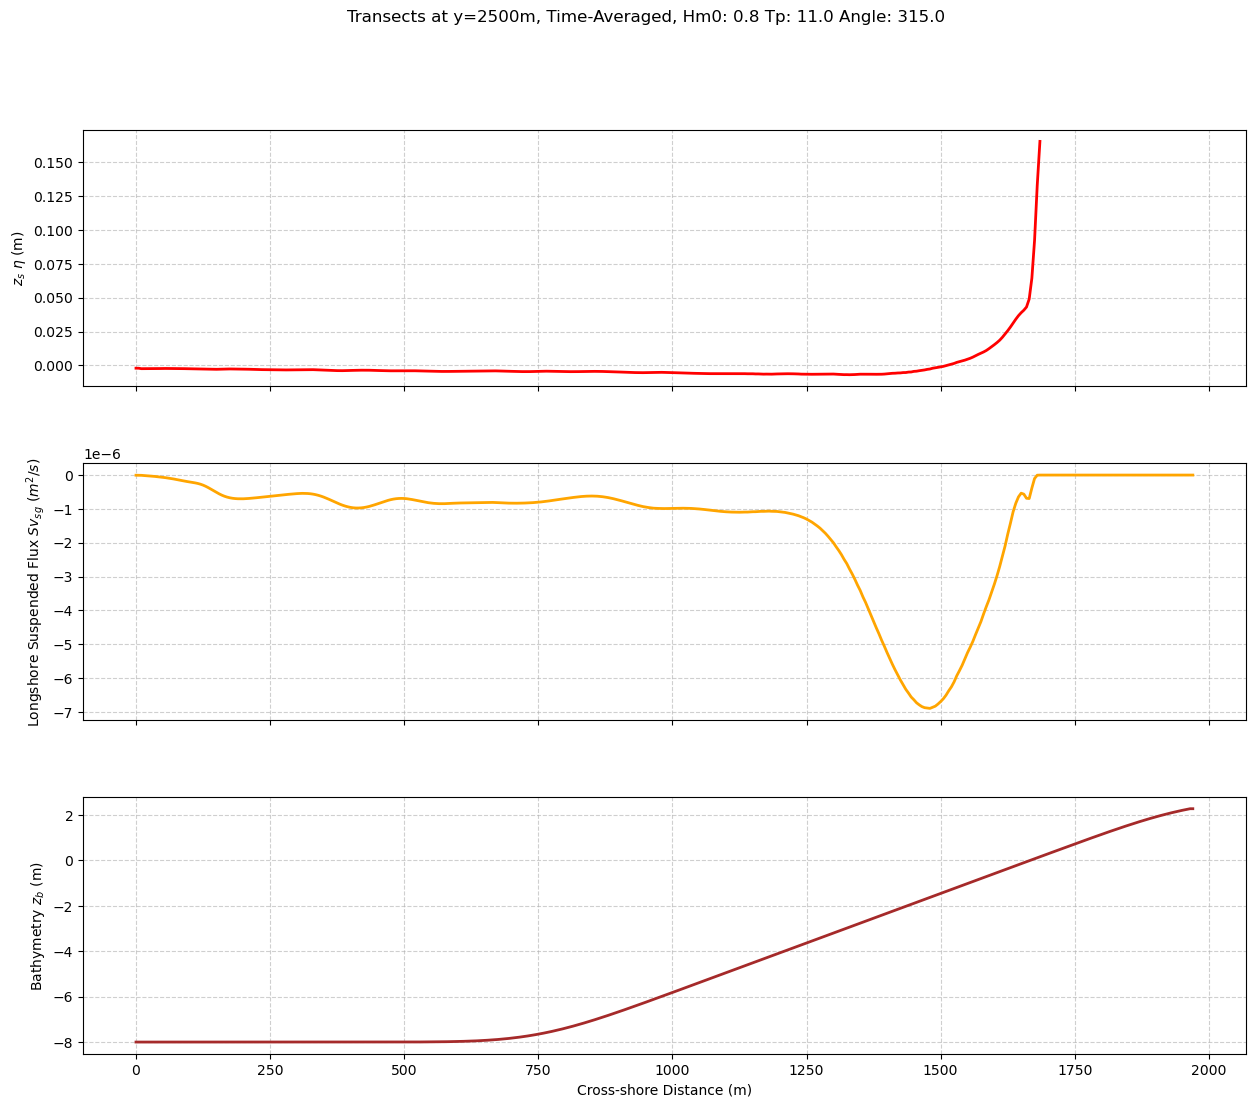

In [36]:
# change y transect value if model space was changed

y_coords = ds['globaly'].isel(nx=0).values
ny_idx = np.abs(y_coords - 2500).argmin()
actual_y = y_coords[ny_idx]
x_coords = ds['globalx'].isel(ny=ny_idx).values

vars_to_plot = [
    ('zs', '$z_s$ $\eta$ (m)', 'red'),
    # ('ve', 'Longshore Current $v_e$ (m/s)', 'green'),
    ('Svsg', 'Longshore Suspended Flux $Sv_{sg}$ ($m^2/s$)', 'orange'),
    ('zb', 'Bathymetry $z_b$ (m)', 'brown')
]

n = len(vars_to_plot)

fig, axes = plt.subplots(n, 1, figsize=(15, 4*n), sharex=True)
plt.subplots_adjust(hspace=0.3)

for i, (var_name, label, color) in enumerate(vars_to_plot):
    data_array = ds[var_name].isel(ny=ny_idx).mean(dim='globaltime')
    data = data_array.values.squeeze()

    axes[i].plot(x_coords, data, color=color, linewidth=2)
    axes[i].set_ylabel(label)
    axes[i].grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel('Cross-shore Distance (m)')
fig.suptitle(f"Transects at y=2500m, Time-Averaged, Hm0: {wave_params['Hm0']} Tp: {wave_params['Tp']} Angle: {wave_params['mainang']}")

plt.show()

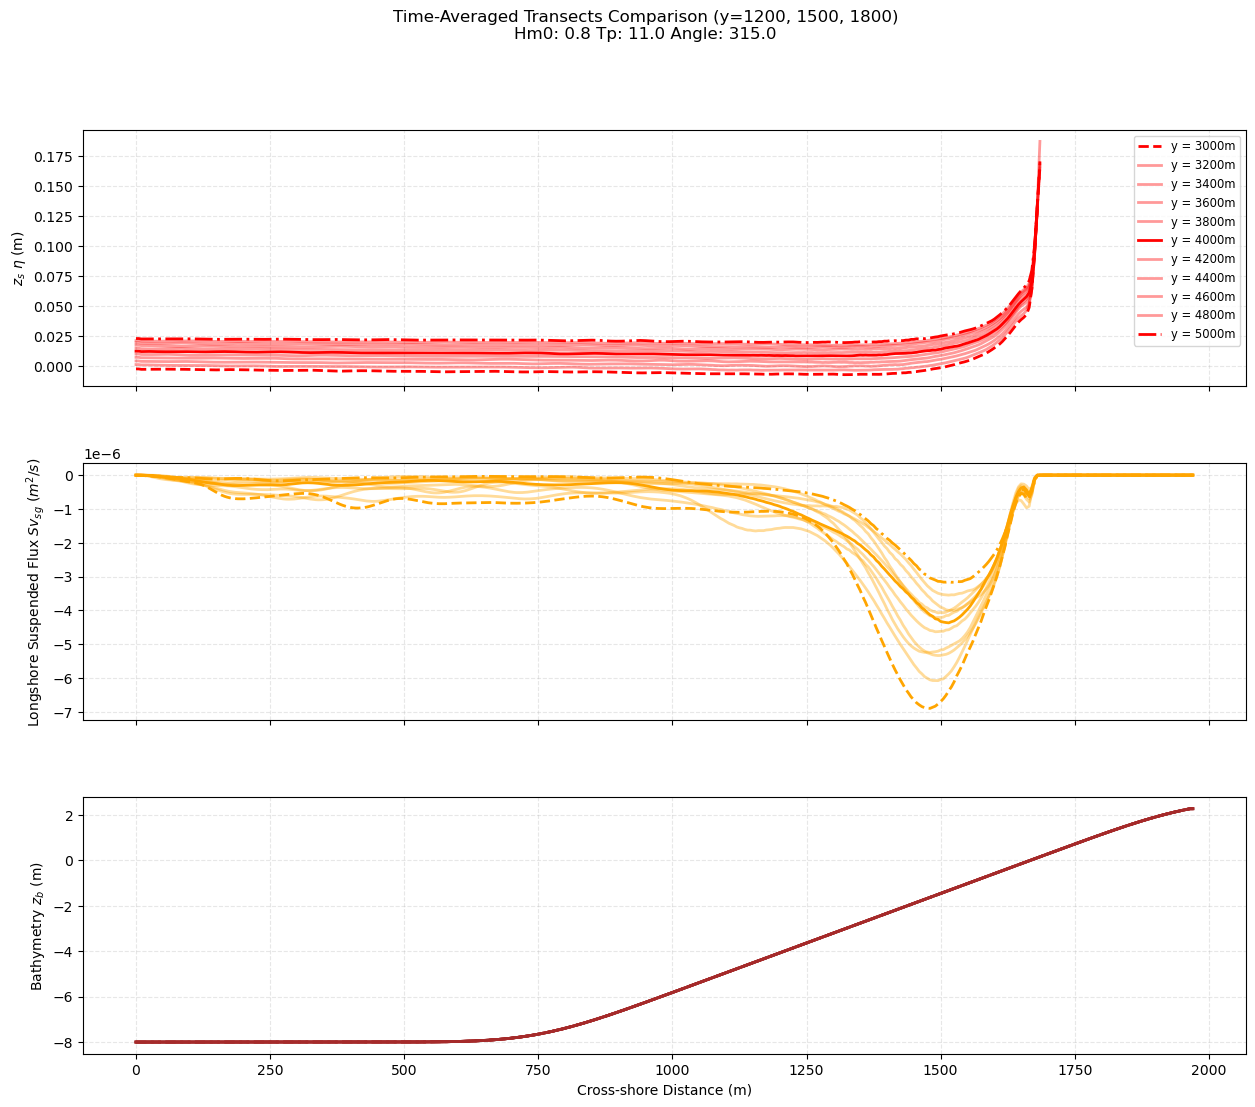

In [40]:
# change y transect values if model space was changed

target_ys = [3000, 3200, 3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800, 5000]
y_coords_full = ds['globaly'].isel(nx=0).values

vars_to_plot = [
    ('zs', '$z_s$ $\eta$ (m)', 'red'),
    # ('ve', 'Longshore Current $v_e$ (m/s)', 'green'),
    ('Svsg', 'Longshore Suspended Flux $Sv_{sg}$ ($m^2/s$)', 'orange'),
    ('zb', 'Bathymetry $z_b$ (m)', 'brown')
]

n = len(vars_to_plot)

fig, axes = plt.subplots(n, 1, figsize=(15, 4*n), sharex=True)
plt.subplots_adjust(hspace=0.3)

line_styles = ['--', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-.']
alphas = [1.0, .4, .4, .4, .4, 1.0, .4, .4, .4, .4, 1.0]

for j, y_target in enumerate(target_ys):
    #find the closest index for specific Y
    ny_idx = np.abs(y_coords_full - y_target).argmin()
    actual_y = y_coords_full[ny_idx]
    x_coords = ds['globalx'].isel(ny=ny_idx).values

    for i, (var_name, label, color) in enumerate(vars_to_plot):
        data_array = ds[var_name].isel(ny=ny_idx).mean(dim='globaltime')
            
        data = data_array.values.squeeze()

        axes[i].plot(x_coords, data, 
                     color=color, 
                     linestyle=line_styles[j], 
                     alpha=alphas[j],
                     linewidth=2, 
                     label=f'y = {actual_y:.0f}m')

        if j == 0:
            axes[i].set_ylabel(label)
            axes[i].grid(True, linestyle='--', alpha=0.3)

axes[0].legend(loc='upper right', fontsize='small')

axes[-1].set_xlabel('Cross-shore Distance (m)')
fig.suptitle(f"Time-Averaged Transects Comparison (y=1200, 1500, 1800)\nHm0: {wave_params['Hm0']} Tp: {wave_params['Tp']} Angle: {wave_params['mainang']}")

plt.show()

In [23]:
# postprocessing for hs
mean_var = ds['zs_var']
mean_var = mean_var.where(mean_var >= 0, np.abs(mean_var))
hs = 4.004 *np.sqrt(mean_var.values)
hs_mean = np.nanmean(hs, axis=0)
hs_ds = xr.Dataset(
    {"hs": (["ny", "nx"], hs_mean)},
    coords={
        "x": (("ny", "nx"), ds['globalx'].values),
        "y": (("ny", "nx"), ds['globaly'].values),
    },
)

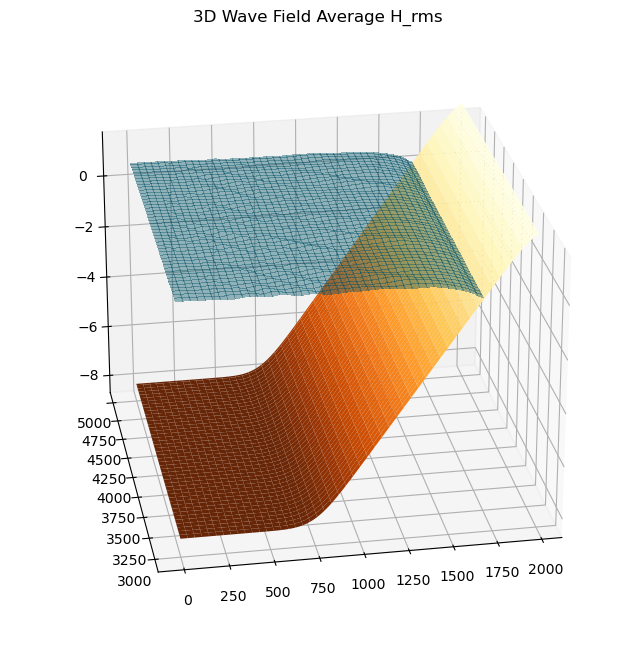

In [24]:
# 3d h_rms plot
X_mesh = ds['globalx'].values 
Y_mesh = ds['globaly'].values

bed = ds['zb'].isel(globaltime=0).values
hs = hs_ds['hs'].values.squeeze()
hs = np.ma.masked_where(hs_mean <= bed, hs_mean)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_mesh, Y_mesh, bed, cmap='YlOrBr_r', linewidth=0, antialiased=True)
ax.plot_surface(X_mesh, Y_mesh, hs, color='#006884',linewidth=0, antialiased=False, alpha=0.4)
ax.set_zlim(np.min(bed)-0.5, 1.5)
ax.set_title(f"3D Wave Field Average H_rms")
ax.view_init(elev=25, azim=-100)

In [25]:
# postprocessing for mean wave direction and current velocity
from scipy.stats import linregress

stride=10
ds_sub = ds.isel(ny=slice(None, None, stride), nx=slice(None, None, stride))

ny_sub = ds_sub.sizes['ny']
nx_sub = ds_sub.sizes['nx']

dzsdx_sub = ds_sub['dzsdx']
dzsdy_sub = ds_sub['dzsdy']

u_sub = ds_sub['u_mean']
v_sub = ds_sub['v_mean']

dirms = np.empty((ny_sub, nx_sub))

for j in range(ny_sub):
    for i in range(nx_sub):
        dzsdx_0, dzsdy_0 = (
            dzsdx_sub[:, j, i].values,
            dzsdy_sub[:, j, i].values,
        )
        if np.all(dzsdx_0 == dzsdx_0.flat[0]) or np.all(dzsdy_0 == dzsdy_0.flat[0]):
            dirms[j, i] = np.nan
        else:
            slope, intercept, _, _, _ = linregress(dzsdx_0, dzsdy_0)
            theta = np.degrees(np.arctan2(slope, 1))
            dirms[j, i] = theta

uu = np.nanmean(ds_sub['u_mean'].values, axis=0)
vv = np.nanmean(ds_sub['v_mean'].values, axis=0)

dir_uv_ds = xr.Dataset(
    {
        "u_mean": (["ny", "nx"], uu),
        "v_mean": (["ny", "nx"], vv),
        "dirs": (["ny", "nx"], dirms),
    },
    coords={
        "x": (("ny", "nx"), ds_sub.globalx.values),
        "y": (("ny", "nx"), ds_sub.globaly.values),
    },
)

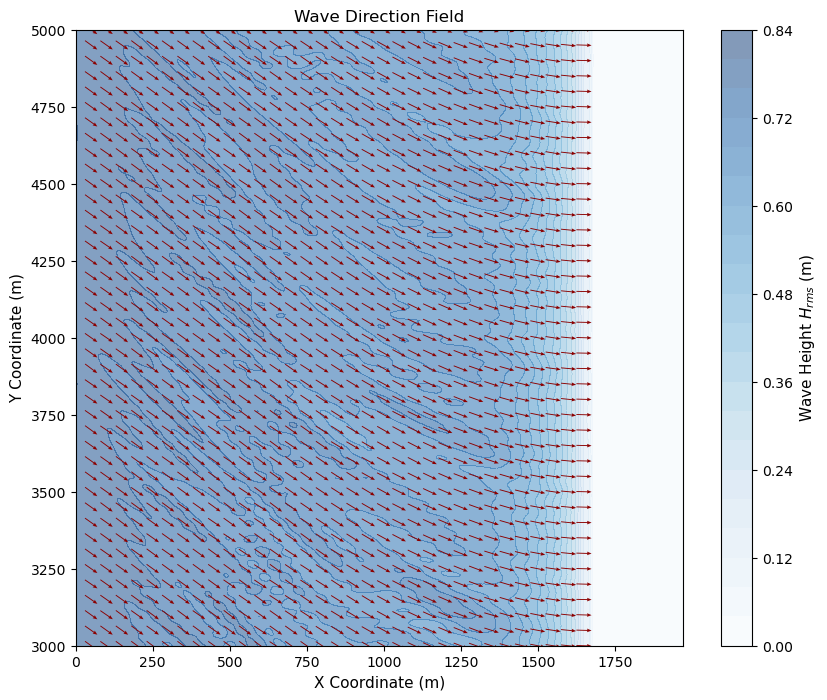

In [32]:
# plot wave direction
X_mesh = ds['globalx'].values
Y_mesh = ds['globaly'].values

X_sub = ds_sub['globalx'].values
Y_sub = ds_sub['globaly'].values

dirms = dir_uv_ds['dirs'].values

angle_rad = np.radians(dirms)
U_dir = np.cos(angle_rad)
V_dir = np.sin(angle_rad)

skip = 5  

fig, ax = plt.subplots(figsize=(10, 8))

background = ax.contourf(
    X_mesh, Y_mesh, hs_ds['hs'].values.squeeze(), 
    cmap='Blues', alpha=0.5, levels=20
)
cbar = fig.colorbar(background, ax=ax)
cbar.set_label("Wave Height $H_{rms}$ (m)", fontsize=11)

quiver = ax.quiver(
    X_sub, 
    Y_sub, 
    U_dir, 
    V_dir,
    color='darkred',
    scale=40,          
    width=0.0015,      
    headwidth=4,        
    pivot='middle'     
)

ax.set_title("Wave Direction Field")
ax.set_xlabel("X Coordinate (m)", fontsize=11)
ax.set_ylabel("Y Coordinate (m)", fontsize=11)
ax.set_aspect('equal')

plt.show()

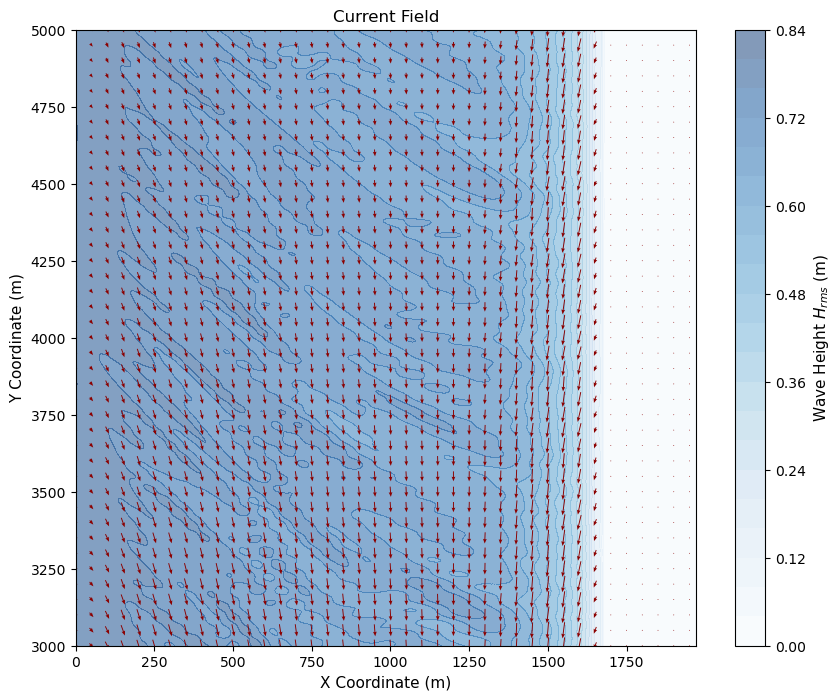

In [33]:
# plot current velocity
X_mesh = ds['globalx'].values
Y_mesh = ds['globaly'].values

X_sub = ds_sub['globalx'].values
Y_sub = ds_sub['globaly'].values

U_dir = dir_uv_ds['u_mean'].values
V_dir = dir_uv_ds['v_mean'].values

fig, ax = plt.subplots(figsize=(10, 8))

background = ax.contourf(
    X_mesh, Y_mesh, hs_ds['hs'].values.squeeze(), 
    cmap='Blues', alpha=0.5, levels=20
)
cbar = fig.colorbar(background, ax=ax)
cbar.set_label("Wave Height $H_{rms}$ (m)", fontsize=11)

quiver = ax.quiver(
    X_sub, 
    Y_sub, 
    U_dir, 
    V_dir,
    color='darkred',
    scale=10,          
    width=0.0015,      
    headwidth=4,        
    pivot='middle'     
)

ax.set_title("Current Field")
ax.set_xlabel("X Coordinate (m)", fontsize=11)
ax.set_ylabel("Y Coordinate (m)", fontsize=11)

plt.show()